# Restaurant Rating Prediction

## Table of Contents

1. [Step 1: Import Libraries](#step-1-import-libraries)
2. [Step 2: Load Dataset](#step-2-load-the-dataset)
3. [Step 3: Target Variable Analysis](#step-3-target-variable-analysis)
4. [Step 4: Exploratory Data Analysis](#step-4-exploratory-data-analysis)
5. [Step 5: Cuisine Feature Engineering](#step-5-cuisine-feature-engineering)
6. [Step 6: Encoding Categorical Features](#step-6-encoding-categorical-features)
7. [Step 7: Feature Selection](#step-7-feature-selection)
8. [Step 8: Train-Test Split](#step-8-train-test-split)
9. [Step 9: Linear Regression Model](#step-9-linear-regression-model)
10. [Step 10: Random Forest Model](#step-10-random-forest-model)
11. [Step 12: Model Tuning](#step-11-model-tuning)
13. [Step 12: Feature Importance](#step-12-feature-importance-analysis)
14. [Step 13: Location Feature Experiment](#step-13-feature-sensitivity-experiment)
15. [Step 14: Prediction Visualization](#step-14-visualizing-actual-vs-predicted-ratings)
16. [Key Insights](#key-insights)

# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Step 2: Load the Dataset

In this section, we load the dataset and inspect its structure.

In [3]:

df = pd.read_csv('../data/Dataset.csv')

df.shape

(9551, 21)

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [6]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Observation

1. We found that there are 9551 entries and 21 columns in this dataset.
2. There are multiple types of data in each column. Some are numeric datatype and some are string type.
3. Each entry has its distinct unique id ('Restaurant Id').
4. The target variable which will be used for further observations is 'Aggregate rating'.


# Step 3: Target Variable Analysis

We analyze the distribution of the Aggregate Rating column.

In [7]:
df['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

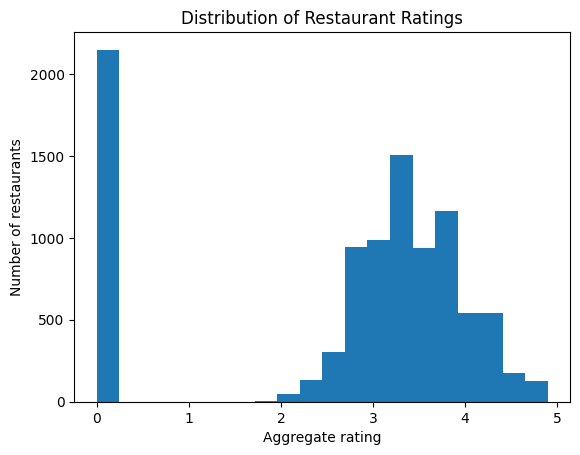

In [8]:

plt.hist(df['Aggregate rating'], bins = 20)
plt.xlabel('Aggregate rating')
plt.ylabel('Number of restaurants')
plt.title('Distribution of Restaurant Ratings')
plt.show()

In [9]:
df[df['Aggregate rating'] == 0]['Votes'].describe()

count    2148.000000
mean        0.870112
std         1.048600
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max         3.000000
Name: Votes, dtype: float64

# Step 4: Exploratory Data Analysis

Restaurants with Aggregate rating = 0 are removed because they represent unrated entries.

In [10]:
df = df[df['Aggregate rating'] > 0]

df.shape

(7403, 21)

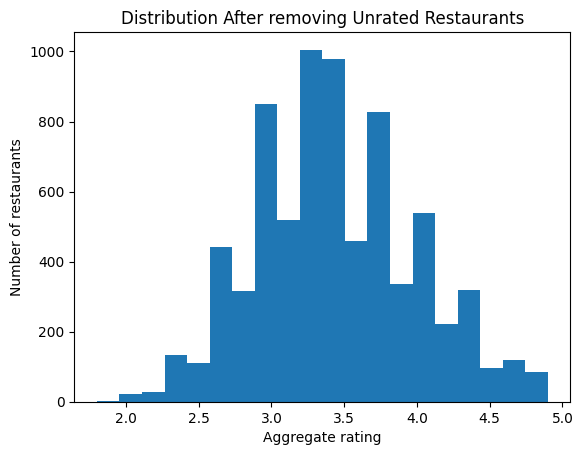

In [11]:
plt.hist(df['Aggregate rating'], bins = 20)
plt.xlabel('Aggregate rating')
plt.ylabel('Number of restaurants')
plt.title('Distribution After removing Unrated Restaurants')
plt.show()


1. On observing the target variable, we found that there were multiple entries where the aggregate rating was 0.
2. To make the target variable accurate, we removed the entries where aggregate rating is 0.
3. After removing the entries, the plot showed a proper distribution.

In [12]:
df.corr(numeric_only = True)

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
Restaurant ID,1.000000,0.255215,-0.280596,-0.017232,0.011218,-0.006848,0.193038,-0.082984
Country Code,0.255215,1.000000,-0.736241,0.010346,0.039305,0.210459,0.412917,0.127652
Longitude,-0.280596,-0.736241,1.000000,-0.097542,0.049345,-0.074384,-0.291458,-0.085230
Latitude,-0.017232,0.010346,-0.097542,1.000000,-0.124947,-0.221437,-0.179917,-0.038285
Average Cost for two,0.011218,0.039305,0.049345,-0.124947,1.000000,0.070638,0.076790,0.063424
Price range,-0.006848,0.210459,-0.074384,-0.221437,0.070638,1.000000,0.403169,0.274103
Aggregate rating,0.193038,0.412917,-0.291458,-0.179917,0.076790,0.403169,1.000000,0.409018
Votes,-0.082984,0.127652,-0.085230,-0.038285,0.063424,0.274103,0.409018,1.000000


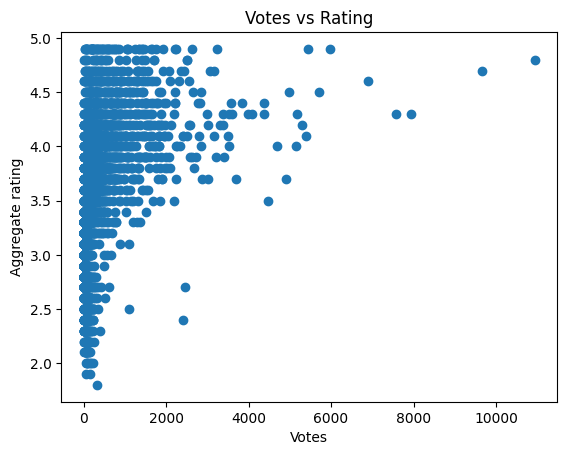

In [13]:
plt.scatter(df['Votes'], df['Aggregate rating'])
plt.xlabel('Votes')
plt.ylabel('Aggregate rating')
plt.title('Votes vs Rating')
plt.show()

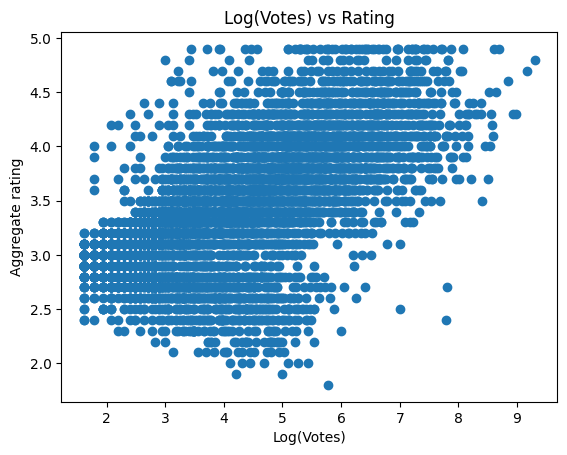

In [14]:

plt.scatter(np.log1p(df['Votes']), df['Aggregate rating'])
plt.xlabel('Log(Votes)')
plt.ylabel('Aggregate rating')
plt.title('Log(Votes) vs Rating')
plt.show()

In [15]:
df.groupby('Price range')['Aggregate rating'].mean()

Price range
1    3.238885
2    3.377167
3    3.777276
4    3.890957
Name: Aggregate rating, dtype: float64

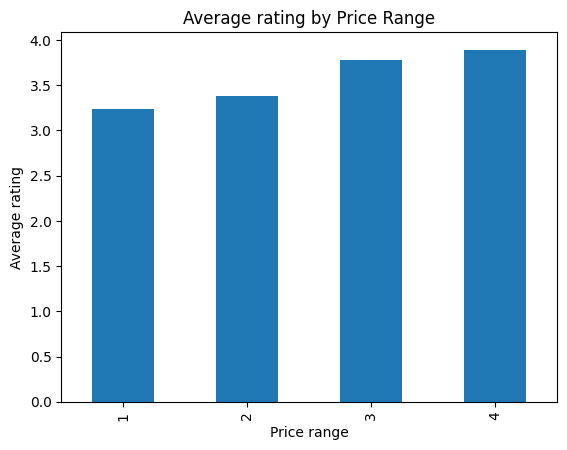

In [16]:

df.groupby('Price range')['Aggregate rating'].mean().plot(kind='bar')
plt.ylabel('Average rating')
plt.title('Average rating by Price Range')
plt.show()


1. There is a positive relationship between price range and average rating.
2. Higher price range tends to have slightly higher ratings.
3. However, price alone cannot be the sole reason for higher ratings.

In [17]:
df.groupby('Price range')['Votes'].mean()

Price range
1     71.713192
2    169.347473
3    455.142025
4    375.624348
Name: Votes, dtype: float64

In [18]:
df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

In [19]:
city_stats = df.groupby('City').agg({
    'Aggregate rating': 'mean',
     'Restaurant ID': 'count'
})

city_stats.columns = ['Average rating', 'Restaurant count']

city_stats.sort_values(by='Restaurant count', ascending=False).head(10)

,Average rating,Restaurant count
City,,
New Delhi,3.297381,4048
Gurgaon,3.330674,890
Noida,3.159626,696
Faridabad,3.103311,151
Ghaziabad,3.100000,23
Bhubaneshwar,3.980952,21
Lucknow,4.195238,21
Guwahati,4.190476,21
Ahmedabad,4.161905,21



1. Cities with a large number of restaurants tends to have more moderate average ratings.
2. Cities with fewer restaurants often show higher average ratings, likely due to smaller sample size.
3. This indicates that location influences ratings, but there is a more complex relationship and it is influenced by restaurant density and customer satisfaction.

# Step 5: Cuisine Feature Engineering

In [20]:
df['Cuisines'].value_counts().head(10)

Cuisines
North Indian                      492
North Indian, Chinese             397
North Indian, Mughlai             294
Cafe                              252
Fast Food                         228
Chinese                           224
North Indian, Mughlai, Chinese    164
Bakery                            130
Bakery, Desserts                  116
Pizza, Fast Food                  113
Name: count, dtype: int64


1. The cuisine column contains both single and multiple cuisine entries.
2. Value count treats each combination as a unique category.
3. This creates high cardinality and requires preprocessing before modeling.

In [21]:
df['Cuisines'].nunique()

1715

In [22]:
# Split cuisines and create a list of all unique cuisine types
all_cuisines = df['Cuisines'].str.split(', ').explode()

unique_cuisines = all_cuisines.unique()

len(unique_cuisines)

144


1. After splitting cuisine combinations, 144 unique cuisine types were identified.
2. However, frequency distribution must be examined to determine whether rare cuisines should be filtered before modeling.

In [23]:
cuisine_counts = all_cuisines.value_counts()
cuisine_counts.head(20)

Cuisines
North Indian    3017
Chinese         2184
Fast Food       1563
Mughlai          794
Italian          726
Continental      699
Cafe             634
Desserts         543
Bakery           536
South Indian     485
Street Food      403
American         380
Pizza            328
Mithai           251
Burger           239
Thai             229
Asian            228
Beverages        177
Mexican          174
Seafood          171
Name: count, dtype: int64

In [24]:
cuisine_counts.tail(20)

Cuisines
Ramen                2
Asian Fusion         2
Taiwanese            2
Izgara               2
Peruvian             1
Gourmet Fast Food    1
Canadian             1
Bubble Tea           1
Irish                1
Soul Food            1
Malay                1
Armenian             1
Persian              1
Malwani              1
Drinks Only          1
Peranakan            1
Fish and Chips       1
Durban               1
D�_ner               1
B�_rek               1
Name: count, dtype: int64


1. Cuisine frequency distribution is highly skewed.
2. A small number of cuisines dominates the dataset, while some appears once or twice.
3. Rare cuisines will be filtered before encoding to prevent overfitting and reduce dimensionality.

In [25]:
# Keep cuisines that appear at least 50 times
frequent_cuisines = cuisine_counts[cuisine_counts >= 50].index

len(frequent_cuisines)

34

# Step 6: Encoding Categorical Features


After analyzing cuisine frequency distribution, only cuisines appearing at least 50 times were retained. This reduced the feature space from 144 individual cuisines to 34 significant cuisines. Filtering rare categories help reduce noise and prevent overfitting.

In [26]:
df['Cuisines'] = df['Cuisines'].fillna('')

In [27]:
# Create binary columns for frequent cuisines
for cuisine in frequent_cuisines:
    df[cuisine] = df['Cuisines'].apply(lambda x: 1 if cuisine in x else 0)


The original Cuisines column was dropped after multi-label encoding. Keeping it would introduce high-level cardinality categorical noise and redundancy. Binary cuisine features sufficiently capture the relevant information while reducing overfitting risk.

In [28]:
df = df.drop(columns = ['Cuisines'])

In [29]:
# Checking the number of unique cities, localities and currencies
df['City'].nunique()


141

In [30]:
df['Locality'].nunique()

1175

In [31]:
df['Currency'].nunique()

12

In [32]:
df = df.drop(columns = ['Restaurant ID', 'City', 'Locality'])


- High-cardinality features such as cities (141 unique values), locality (1175 unique values) were removed to prevent dimensional explosion and overfitting.
- Currency (12 unique values) was retained due to manageable cardinality and potential economic relevance.
- Restaurant ID was dropped as it acts as an identifier and carries no predictive value.

In [33]:
df = pd.get_dummies(df, columns = ['Currency'], drop_first = True)

We chose the Aggregate Rating as the target variable. So, if we include 'Rating color' and 'Rating text' as features for the dataset, it will cause data leakage. This means my model will see the information that reveals the target. So, for better performance, we will drop these columns.

In [34]:
df = df.drop(columns = ['Rating text', 'Rating color'])

In [35]:
df = df.drop(columns = ['Restaurant Name', 'Address', 'Locality Verbose'])

In [36]:
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Is delivering now'] = df['Is delivering now'].map({'Yes': 1, 'No': 0})
df['Switch to order menu'] = df['Switch to order menu'].map({'Yes': 1, 'No': 0})

# Step 7: Feature Selection

In [37]:
X = df.drop(columns = ['Aggregate rating'])
y = df['Aggregate rating']

In [38]:
(X.dtypes == 'object').sum()

np.int64(0)

- Inspected the datatypes of each column to identify no-numeric columns. Then, we removed the string columns like 'Restaurant Name, Address, Locality' because they were identifiers, not predictive patterns.
- Converted Yes/No style features into numeric values (0 and 1) as binary representation makes them usable.
- Encoded cuisine values into binary columns for reduced overfitting, then removed the original cuisine column.

# Step 8: Train-Test Split


In [39]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

- Split the dataset into 80-20 for training and testing to evaluate model on unseen data and measure generalization.

# Step 9: Linear Regression model

We will train a baseline model using Linear Regression to compare it with advanced methods.

In [40]:

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse) 
print('R2 Score:', r2)

MSE: 0.16932023677475216
R2 Score: 0.45253504999454985


- Trained Linear Regression Model. The resulting R<sup>2</sup> score was around 0.45, which showed linear relationship exists but is limited.

In [42]:
np.sqrt(mse)

np.float64(0.4114854028695941)

# Step 10: Random Forest Model

We will train a more advanced model using Random Forest. It captures non-linear relationships and feature interactions.

In [43]:

rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print('Random Forest MSE:', mse_rf)
print('Random Forest R2 Score:', r2_rf)

Random Forest MSE: 0.10834649773126262
Random Forest R2 Score: 0.6496820988821339


In [44]:
train_r2_rf = r2_score(y_train, rf.predict(X_train))
test_r2_rf = r2_score(y_test, y_pred_rf)

print('Train R2:', train_r2_rf)
print('Test R2:', test_r2_rf)

Train R2: 0.9451491515918126
Test R2: 0.6496820988821339


- Trained Non-linear Random Forest model. Resulting R<sup>2</sup> score was 0.94 (train) and 0.65 (test). This means there is severe overfitting as the model memorized too many patterns in the training data.

# Step 11: Model Tuning

Tune Random Forest model to reduce overfitting and improve generalization. 

In [45]:
rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

train_r2_tuned = r2_score(y_train, rf_tuned.predict(X_train))
test_r2_tuned = r2_score(y_test, y_pred_tuned)

print("Train R2:", train_r2_tuned)
print("Test R2:", test_r2_tuned)


Train R2: 0.7523283239889968
Test R2: 0.6487257893506195


- Restricted Tree depth to reduce complexity. The resulting R<sup>2</sup> score was 0.75 (train) and 0.65 (test). This showed model generalization improved and overfitting is significantly reduced.

In [46]:
mse = mean_squared_error(y_test, y_pred_tuned)
print('Mean Squared Error:', mse)

Mean Squared Error: 0.1086422656270966


# Step 12: Feature Importance Analysis

Analyzing which features are important to the model's predictions.

In [47]:
feature_importances = pd.Series(
    rf_tuned.feature_importances_,
    index = X_train.columns
).sort_values(ascending = False)

feature_importances.head(10)

Votes                          0.582333
Longitude                      0.102350
Latitude                       0.083885
Country Code                   0.046693
Average Cost for two           0.035868
Chinese                        0.018986
Currency_Indian Rupees(Rs.)    0.013420
Pizza                          0.012602
Indian                         0.010522
Continental                    0.008914
dtype: float64

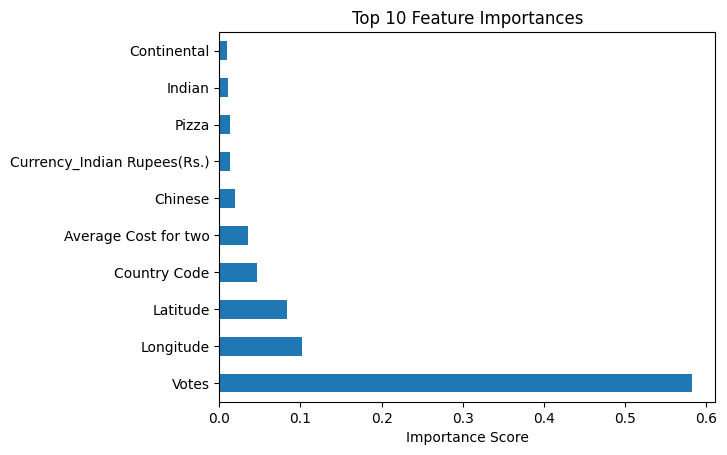

In [48]:
feature_importances.head(10).plot(kind = 'barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.show()

- The model identified votes, geographical locations, and price range as the most influential features in predicting the restaurant ratings. 
- Some cuisine categories also showed moderate importance, indicating that restaurant type may influence customer perception of quality.

# Step 13: Feature Sensitivity Experiment

Removing latitude and longitude features to test how dependent the model is on location.

In [49]:
# Testing the Model dependency without Location
X_no_location = X.drop(['Latitude', 'Longitude'], axis = 1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_location, y, test_size = 0.2, random_state = 42
)

In [50]:
rf_no_location = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_no_location.fit(X_train2, y_train2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [51]:
y_pred2 = rf_no_location.predict(X_test2)

train_r2_2 = r2_score(y_train2, rf_no_location.predict(X_train2))
test_r2_2 = r2_score(y_test2, y_pred2)

print('Train R2_2:', train_r2_2)
print('Test R2_2:', test_r2_2)

Train R2_2: 0.7235139086311724
Test R2_2: 0.6239283414077627


Geographic features slightly improve model performance, but the model retains strong predictive ability without them, indicating that other variables such as customer engagement and pricing play a larger role in predicting the ratings.  

# Step 14: Visualizing Actual vs. Predicted Ratings

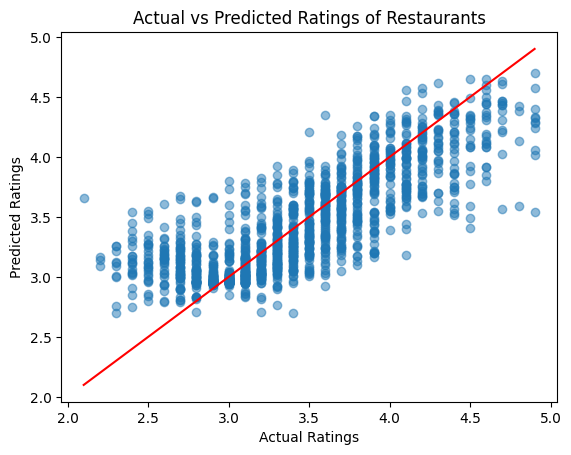

In [52]:

plt.scatter(y_test, y_pred_tuned, alpha = 0.5)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings of Restaurants')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color = 'red')
plt.show()

The plot shows that most predictions lie close to the ideal diagonal line, indicating that the model captures the ratings trend effectively. While some spread around the line, the clustering pattern suggests that the model produces reasonably accurate predictions. Slight underestimation is observed for very high ratings, which is common in ensemble models.

# Key Insights

 
1.  **Customer Engagement Strongly Influences Ratings** - The number of votes was the most important predictor in the model. Restaurants with a higher number of customer votes tend to have more stable and higher ratings. This suggests that customer engagement and popularity played a significant role in determining the restaurant ratings.

2. **Geographic Location has a Moderate Impact** - Geographic features such as longitude and latitude showed some influence on the model's prediction. However, after removing these features, the model's performance decreased only slightly (R<sup>2</sup> dropped from ~0.65 to ~0.62). This indicates that while location contributes to rating prediction, it is not the primary factor.

3. **Pricing Level shows a Positive Relationship with Ratings** - The analysis revealed that restaurants with higher price range tend to have higher average ratings. This showed that customers often associate higher-priced restaurants with better quality or service.

4. **Certain Cuisine Types Influence Ratings** - After encoding the cuisine types, a few cuisine categories appeared among the important features in the model. This suggests certain types of cuisine may consistently recieve higher customer ratings compared to others.

5. **Non-Linear Model Perform Better for this Dataset** - A Random Forest significantly outperformed Linear Regression in predicting restaurant ratings. This indicates that the dataset contains non-linear relationships and complex features that tree-based models can capture more effectively. 
